# 📘 Phase 1 — Fondations Python & Librairies ML

**Objectif de ce notebook :**
- Maîtriser les librairies essentielles : NumPy, Pandas, Matplotlib, Seaborn
- Charger et explorer des données réelles
- Se préparer pour les phases suivantes du ML

---
> 💡 **Comment utiliser ce notebook ?**  
> Exécutez chaque cellule avec **Shift + Enter**. Lisez l'explication avant chaque bloc de code.

## 🔧 Étape 1 — Vérification de l'environnement

On commence par vérifier que toutes les librairies sont bien installées.

In [3]:
# Vérification des versions installées
import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

print(f'✅ Python      : {sys.version.split()[0]}')
print(f'✅ NumPy       : {np.__version__}')
print(f'✅ Pandas      : {pd.__version__}')
print(f'✅ Matplotlib  : {matplotlib.__version__}')
print(f'✅ Seaborn     : {sns.__version__}')
print(f'✅ Scikit-learn: {sklearn.__version__}')
print('\n🚀 Environnement prêt !')

✅ Python      : 3.10.9
✅ NumPy       : 2.2.6
✅ Pandas      : 2.3.3
✅ Matplotlib  : 3.10.0
✅ Seaborn     : 0.13.2
✅ Scikit-learn: 1.7.1

🚀 Environnement prêt !


---
## 📐 Étape 2 — NumPy : La base du calcul scientifique

**NumPy** = Numerical Python. C'est la librairie de base pour manipuler des **tableaux de nombres** très rapidement.

### Pourquoi NumPy ?
- 100x plus rapide que les listes Python standard
- Tous les algorithmes ML utilisent NumPy en interne
- Opérations mathématiques vectorisées (pas de boucles)

In [4]:
import numpy as np

# --- 2.1 Créer un tableau NumPy (array) ---
# Imaginez des ventes journalières en TND
ventes = np.array([1200, 850, 1500, 2100, 980, 1750, 3000])
print('Ventes journalières (TND):', ventes)
print('Type:', type(ventes))
print('Shape (taille):', ventes.shape)  # (7,) = 7 éléments

Ventes journalières (TND): [1200  850 1500 2100  980 1750 3000]
Type: <class 'numpy.ndarray'>
Shape (taille): (7,)


In [5]:
# --- 2.2 Statistiques de base ---
print(f'Total ventes     : {ventes.sum():,.0f} TND')
print(f'Moyenne          : {ventes.mean():,.0f} TND')
print(f'Vente max        : {ventes.max():,.0f} TND')
print(f'Vente min        : {ventes.min():,.0f} TND')
print(f'Écart-type       : {ventes.std():,.0f} TND')

Total ventes     : 11,380 TND
Moyenne          : 1,626 TND
Vente max        : 3,000 TND
Vente min        : 850 TND
Écart-type       : 691 TND


In [6]:
# --- 2.3 Opérations vectorisées (sans boucle!) ---
# Appliquer une TVA de 19% sur toutes les ventes d'un coup
tva = 0.19
ventes_ttc = ventes * (1 + tva)
print('Ventes HT :', ventes)
print('Ventes TTC:', ventes_ttc.astype(int))

Ventes HT : [1200  850 1500 2100  980 1750 3000]
Ventes TTC: [1428 1011 1785 2499 1166 2082 3570]


In [5]:
# --- 2.4 Tableau 2D (matrice) ---
# Lignes = jours, Colonnes = [ventes, quantités, prix_moyen]
donnees = np.array([
    [1200, 5, 240],
    [850,  3, 283],
    [1500, 8, 187],
    [2100, 10, 210],
    [980,  4, 245]
])
print('Matrice de données:')
print(donnees)
print(f'\nShape: {donnees.shape}  →  {donnees.shape[0]} jours × {donnees.shape[1]} colonnes')

Matrice de données:
[[1200    5  240]
 [ 850    3  283]
 [1500    8  187]
 [2100   10  210]
 [ 980    4  245]]

Shape: (5, 3)  →  5 jours × 3 colonnes


In [6]:
# --- 2.5 Indexation et Slicing ---
print('Jour 1 (index 0)         :', donnees[0])        # Première ligne
print('Colonne ventes           :', donnees[:, 0])     # Toutes les ventes
print('Jours 2 à 4              :', donnees[1:4])      # Lignes 1,2,3

# Filtrage conditionnel
ventes_elevees_mask = donnees[:, 0] > 1000
print('\nJours avec ventes > 1000 TND:')
print(donnees[ventes_elevees_mask])

Jour 1 (index 0)         : [1200    5  240]
Colonne ventes           : [1200  850 1500 2100  980]
Jours 2 à 4              : [[ 850    3  283]
 [1500    8  187]
 [2100   10  210]]

Jours avec ventes > 1000 TND:
[[1200    5  240]
 [1500    8  187]
 [2100   10  210]]


---
## 🐼 Étape 3 — Pandas : Manipulation des données tabulaires

**Pandas** = La librairie la plus importante pour un Data Scientist.  
Elle fonctionne avec des **DataFrames** (comme des feuilles Excel en Python).

### Concepts clés :
- **Series** : une colonne (1D)
- **DataFrame** : un tableau complet (2D, lignes + colonnes)

In [7]:
import pandas as pd

# --- 3.1 Créer un DataFrame manuellement ---
data = {
    'date'       : pd.date_range('2025-01-01', periods=7, freq='D'),
    'produit'    : ['Robe', 'Hijab', 'Robe', 'Écharpe', 'Hijab', 'Robe', 'Écharpe'],
    'categorie'  : ['Femme', 'Femme', 'Femme', 'Accessoire', 'Femme', 'Femme', 'Accessoire'],
    'ventes_tnd' : [1200, 850, 1500, 2100, 980, 1750, 3000],
    'quantite'   : [5, 3, 8, 10, 4, 7, 12],
    'plateforme' : ['Instagram', 'Facebook', 'Instagram', 'Instagram', 'Facebook', 'Instagram', 'Facebook']
}

df = pd.DataFrame(data)
print('Notre DataFrame:')
df

Notre DataFrame:


,date,produit,categorie,ventes_tnd,quantite,plateforme
0,2025-01-01,Robe,Femme,1200,5,Instagram
1,2025-01-02,Hijab,Femme,850,3,Facebook
2,2025-01-03,Robe,Femme,1500,8,Instagram
3,2025-01-04,Écharpe,Accessoire,2100,10,Instagram
4,2025-01-05,Hijab,Femme,980,4,Facebook
5,2025-01-06,Robe,Femme,1750,7,Instagram
6,2025-01-07,Écharpe,Accessoire,3000,12,Facebook


In [8]:
# --- 3.2 Informations générales sur le DataFrame ---
print('=== SHAPE (lignes, colonnes) ===')
print(df.shape)

print('\n=== TYPES DES COLONNES ===')
print(df.dtypes)

print('\n=== STATISTIQUES DESCRIPTIVES ===')
df.describe()

=== SHAPE (lignes, colonnes) ===
(7, 6)

=== TYPES DES COLONNES ===
date          datetime64[ns]
produit               object
categorie             object
ventes_tnd             int64
quantite               int64
plateforme            object
dtype: object

=== STATISTIQUES DESCRIPTIVES ===


,date,ventes_tnd,quantite
count,7,7.000000,7.000000
mean,2025-01-04 00:00:00,1625.714286,7.000000
min,2025-01-01 00:00:00,850.000000,3.000000
25%,2025-01-02 12:00:00,1090.000000,4.500000
50%,2025-01-04 00:00:00,1500.000000,7.000000
75%,2025-01-05 12:00:00,1925.000000,9.000000
max,2025-01-07 00:00:00,3000.000000,12.000000
std,NaN,746.633715,3.265986


In [9]:
# --- 3.3 Sélection de colonnes ---
# Une seule colonne → Series
print('Colonne ventes:')
print(df['ventes_tnd'])

print('\nPlusieurs colonnes → DataFrame:')
print(df[['produit', 'ventes_tnd', 'quantite']])

Colonne ventes:
0    1200
1     850
2    1500
3    2100
4     980
5    1750
6    3000
Name: ventes_tnd, dtype: int64

Plusieurs colonnes → DataFrame:
   produit  ventes_tnd  quantite
0     Robe        1200         5
1    Hijab         850         3
2     Robe        1500         8
3  Écharpe        2100        10
4    Hijab         980         4
5     Robe        1750         7
6  Écharpe        3000        12


In [10]:
# --- 3.4 Filtrage des données ---
# Ventes supérieures à 1000 TND
print('Ventes > 1000 TND:')
print(df[df['ventes_tnd'] > 1000])

print('\nSeulement Instagram ET ventes > 1000:')
print(df[(df['plateforme'] == 'Instagram') & (df['ventes_tnd'] > 1000)])

Ventes > 1000 TND:
        date  produit   categorie  ventes_tnd  quantite plateforme
0 2025-01-01     Robe       Femme        1200         5  Instagram
2 2025-01-03     Robe       Femme        1500         8  Instagram
3 2025-01-04  Écharpe  Accessoire        2100        10  Instagram
5 2025-01-06     Robe       Femme        1750         7  Instagram
6 2025-01-07  Écharpe  Accessoire        3000        12   Facebook

Seulement Instagram ET ventes > 1000:
        date  produit   categorie  ventes_tnd  quantite plateforme
0 2025-01-01     Robe       Femme        1200         5  Instagram
2 2025-01-03     Robe       Femme        1500         8  Instagram
3 2025-01-04  Écharpe  Accessoire        2100        10  Instagram
5 2025-01-06     Robe       Femme        1750         7  Instagram


In [11]:
# --- 3.5 Créer de nouvelles colonnes ---
# Prix moyen par article
df['prix_moyen'] = df['ventes_tnd'] / df['quantite']

# Jour de la semaine (feature temporelle utile pour le ML !)
df['jour_semaine'] = df['date'].dt.day_name()

# Catégorie de performance
df['performance'] = df['ventes_tnd'].apply(lambda x: 'Élevée' if x > 1500 else 'Normale')

print('DataFrame enrichi:')
df

DataFrame enrichi:


,date,produit,categorie,ventes_tnd,quantite,plateforme,prix_moyen,jour_semaine,performance
0,2025-01-01,Robe,Femme,1200,5,Instagram,240.000000,Wednesday,Normale
1,2025-01-02,Hijab,Femme,850,3,Facebook,283.333333,Thursday,Normale
2,2025-01-03,Robe,Femme,1500,8,Instagram,187.500000,Friday,Normale
3,2025-01-04,Écharpe,Accessoire,2100,10,Instagram,210.000000,Saturday,Élevée
4,2025-01-05,Hijab,Femme,980,4,Facebook,245.000000,Sunday,Normale
5,2025-01-06,Robe,Femme,1750,7,Instagram,250.000000,Monday,Élevée
6,2025-01-07,Écharpe,Accessoire,3000,12,Facebook,250.000000,Tuesday,Élevée


In [12]:
# --- 3.6 GroupBy — Agrégation par groupe ---
print('=== Ventes totales par produit ===')
print(df.groupby('produit')['ventes_tnd'].sum().sort_values(ascending=False))

print('\n=== Moyenne des ventes par plateforme ===')
print(df.groupby('plateforme')[['ventes_tnd', 'quantite']].mean().round(0))

=== Ventes totales par produit ===
produit
Écharpe    5100
Robe       4450
Hijab      1830
Name: ventes_tnd, dtype: int64

=== Moyenne des ventes par plateforme ===
            ventes_tnd  quantite
plateforme                      
Facebook        1610.0       6.0
Instagram       1638.0       8.0


In [43]:
# --- 3.7 Charger un fichier Excel réel ---
import os

excel_path = r'c:\4_ERP_BI\Semestre_2\E-commerce\handmade_tunisia_20260202_232135.xlsx'

if os.path.exists(excel_path):
    df_reel = pd.read_excel(excel_path)
    print(f'✅ Fichier chargé : {df_reel.shape[0]} lignes × {df_reel.shape[1]} colonnes')
    print('\nColonnes disponibles:')
    print(df_reel.columns.tolist())
    print('\nAperçu (5 premières lignes):')
    display(df_reel.head())
else:
    print('⚠️  Fichier non trouvé — on continue avec les données simulées.')
    

✅ Fichier chargé : 124 lignes × 9 colonnes

Colonnes disponibles:
['Nom du Produit', 'Catégorie', 'Description', 'Prix', 'Caractéristiques', 'URL Produit', 'Image', 'Alt Image', 'Site']

Aperçu (5 premières lignes):


,Nom du Produit,Catégorie,Description,Prix,Caractéristiques,URL Produit,Image,Alt Image,Site
0,Bonbonnière avec couvercle en cuivre martelé,ACCUEIL - TOUS PRODUITS,Tapis & margoum\nDÉCOUVRIR\nBOIS D'OLIVIER\nDé...,95.0,Bonbonnière avec couvercle en cuivre martelé\n...,NaN,https://www.handmadetunisia.com/wp-content/upl...,Hand and crafts,Handmade Tunisia
1,Bonbonnière avec couvercle en cuivre martelé,ACCUEIL - TOUS PRODUITS,NaN,95.0,NaN,https://www.handmadetunisia.com/produit/bonbon...,https://www.handmadetunisia.com/wp-content/upl...,Bonbonnière-avec-couvercle-en-cuivre-martelé,Handmade Tunisia
2,Grand planche à découper,ACCUEIL - TOUS PRODUITS,NaN,30.0,NaN,https://www.handmadetunisia.com/produit/grand-...,https://www.handmadetunisia.com/wp-content/upl...,Planch-céramique-houta-marron,Handmade Tunisia
3,Planche à découper Mosaic,ACCUEIL - TOUS PRODUITS,NaN,30.0,NaN,https://www.handmadetunisia.com/produit/grand-...,https://www.handmadetunisia.com/wp-content/upl...,mozaic-cutting-board,Handmade Tunisia
4,Planche à servir et à découper ronde,ACCUEIL - TOUS PRODUITS,NaN,25.0,NaN,https://www.handmadetunisia.com/produit/planch...,https://www.handmadetunisia.com/wp-content/upl...,Planche à servir et à découper ronde,Handmade Tunisia


---
## 📊 Étape 4 — Matplotlib : Visualisation de base

**Matplotlib** est la librairie de visualisation principale en Python.  
On l'utilise pour créer des graphiques précis et personnalisables.

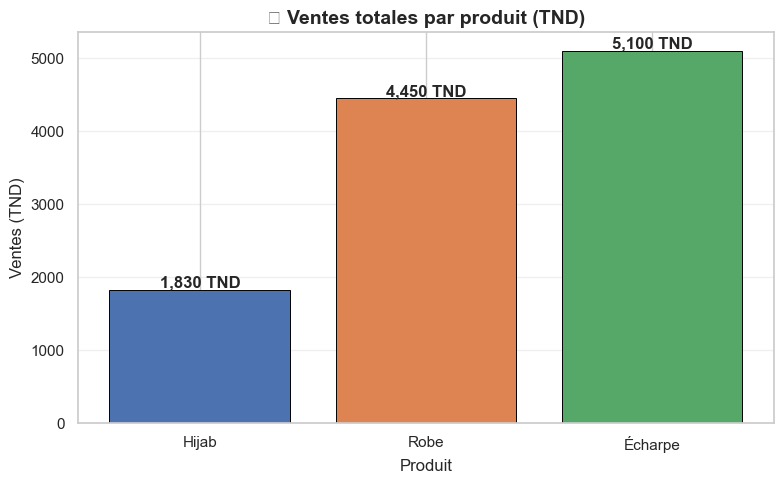

✅ Graphique sauvegardé dans reports/


In [44]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)  # Taille par défaut
matplotlib.rcParams['font.size'] = 12

# --- 4.1 Graphique en barres : Ventes par produit ---
ventes_produit = df.groupby('produit')['ventes_tnd'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ventes_produit.index, ventes_produit.values,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', linewidth=0.7)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, ventes_produit.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,} TND', ha='center', fontweight='bold')

ax.set_title('💰 Ventes totales par produit (TND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Produit')
ax.set_ylabel('Ventes (TND)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'c:\4_ERP_BI\Semestre_2\E-commerce\ML_Engineering\reports\ventes_par_produit.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé dans reports/')

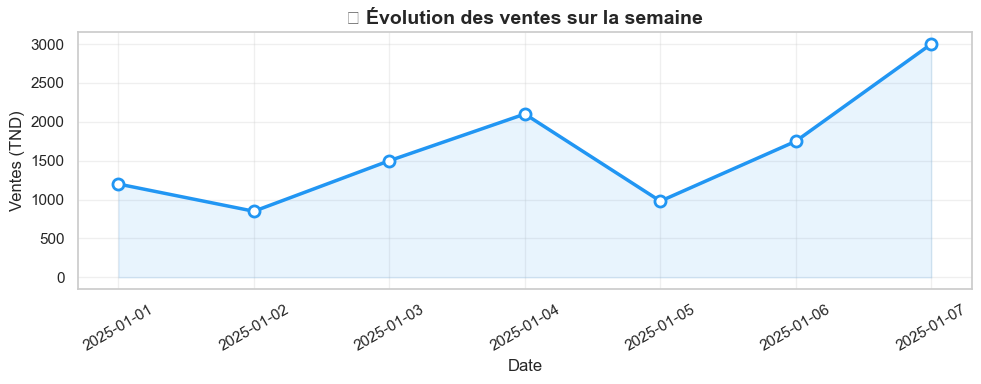

In [45]:
# --- 4.2 Graphique en ligne : Évolution temporelle ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['date'], df['ventes_tnd'], marker='o', linewidth=2.5,
        color='#2196F3', markerfacecolor='white', markeredgewidth=2, markersize=8)

# Zone colorée sous la courbe
ax.fill_between(df['date'], df['ventes_tnd'], alpha=0.1, color='#2196F3')

ax.set_title('📈 Évolution des ventes sur la semaine', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Ventes (TND)')
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

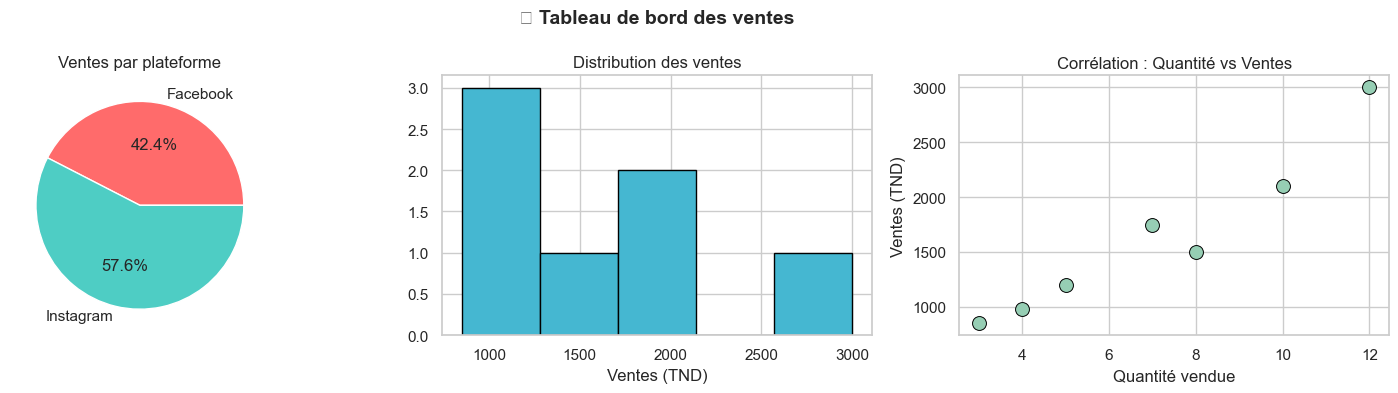

In [46]:
# --- 4.3 Sous-graphiques multiples (subplots) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Graphique 1 : Pie chart par plateforme
ventes_plat = df.groupby('plateforme')['ventes_tnd'].sum()
axes[0].pie(ventes_plat, labels=ventes_plat.index, autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Ventes par plateforme')

# Graphique 2 : Histogramme des ventes
axes[1].hist(df['ventes_tnd'], bins=5, color='#45B7D1', edgecolor='black')
axes[1].set_title('Distribution des ventes')
axes[1].set_xlabel('Ventes (TND)')

# Graphique 3 : Scatter plot ventes vs quantités
axes[2].scatter(df['quantite'], df['ventes_tnd'], c='#96CEB4',
                s=100, edgecolors='black', linewidth=0.7)
axes[2].set_title('Corrélation : Quantité vs Ventes')
axes[2].set_xlabel('Quantité vendue')
axes[2].set_ylabel('Ventes (TND)')

plt.suptitle('📊 Tableau de bord des ventes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎨 Étape 5 — Seaborn : Visualisation statistique avancée

**Seaborn** est construit sur Matplotlib et offre des graphiques statistiques plus beaux et plus informatifs avec moins de code.

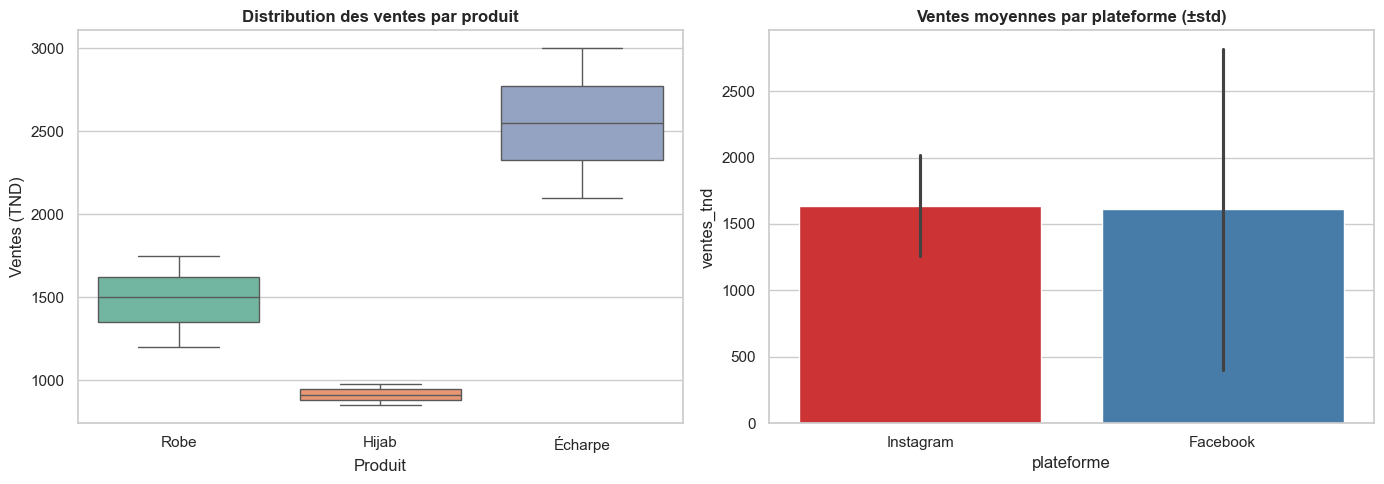

In [47]:
import seaborn as sns
sns.set_theme(style='whitegrid', palette='husl')  # Thème global Seaborn

# --- 5.1 Boxplot : Distribution par catégorie ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='produit', y='ventes_tnd', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution des ventes par produit', fontweight='bold')
axes[0].set_xlabel('Produit')
axes[0].set_ylabel('Ventes (TND)')

sns.barplot(data=df, x='plateforme', y='ventes_tnd', ax=axes[1],
            palette='Set1', estimator='mean', errorbar='sd')
axes[1].set_title('Ventes moyennes par plateforme (±std)', fontweight='bold')

plt.tight_layout()
plt.show()

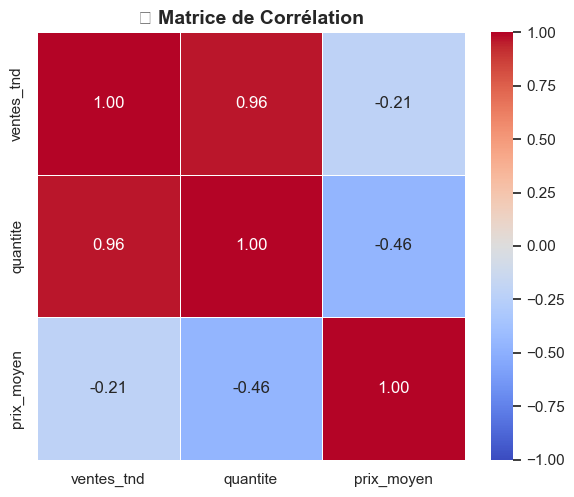


📌 Interprétation:
  - ventes vs quantite : 0.96 → Plus on vend de quantités, plus les ventes augmentent ✅


In [48]:
# --- 5.2 Heatmap de corrélation ---
# La corrélation = relation entre deux variables (-1 à +1)
# +1 = corrélation positive parfaite
#  0 = aucune corrélation
# -1 = corrélation négative parfaite

corr_matrix = df[['ventes_tnd', 'quantite', 'prix_moyen']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('🔗 Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Interprétation:')
print('  - ventes vs quantite :', round(corr_matrix.loc['ventes_tnd','quantite'], 2),
      '→ Plus on vend de quantités, plus les ventes augmentent ✅')

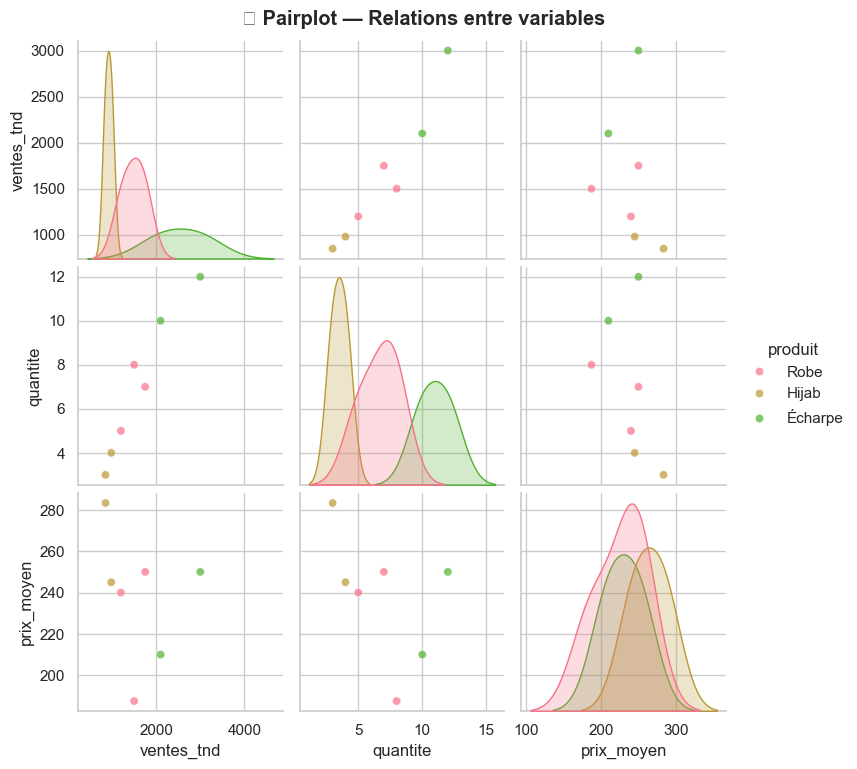

In [49]:
# --- 5.3 Pairplot — Voir toutes les relations d'un coup ---
sns.pairplot(df[['ventes_tnd', 'quantite', 'prix_moyen', 'produit']],
             hue='produit', plot_kws={'alpha': 0.7})
plt.suptitle('🔍 Pairplot — Relations entre variables', y=1.02, fontweight='bold')
plt.show()

---
## 🔌 Étape 6 — Connexion à SQL Server (optionnel)

Si vous avez SQL Server avec la table `FACT_ACTIVITE`, on peut se connecter directement.  
**Sinon, passez à l'étape suivante** — on utilisera les fichiers Excel.

In [7]:
# --- 6.1 Test de connexion SQL Server ---
from sqlalchemy import create_engine, text
import urllib


# ⚠️ MODIFIEZ ces paramètres selon votre configuration
SERVER   = 'GEORGE\MSSQLSERVER03'          # ou '.' ou 'DESKTOP-XXX\SQLEXPRESS'
DATABASE = 'DWH_ARTISANAT'       # Nom de votre Data Warehouse

try:
    conn_str = (
        f'DRIVER={{ODBC Driver 17 for SQL Server}};'
        f'SERVER={SERVER};'
        f'DATABASE={DATABASE};'
        f'Trusted_Connection=yes;'
    )
    params = urllib.parse.quote_plus(conn_str)
    engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

    with engine.connect() as conn:
        result = conn.execute(text('SELECT COUNT(*) FROM FACT_ACTIVITE'))
        count = result.fetchone()[0]
        print(f'✅ Connexion réussie ! FACT_ACTIVITE contient {count:,} lignes.')

except Exception as e:
    print(f'⚠️  Connexion SQL Server non disponible : {e}')
    print('→ Continuez avec les fichiers Excel dans les prochaines étapes.')

✅ Connexion réussie ! FACT_ACTIVITE contient 659 lignes.


In [12]:
# --- 6.2 Charger FACT_ACTIVITE si connexion OK ---
# Version finale - sans tentative Parquet

try:
    query = """
    SELECT TOP 1000
        fa.*,
        dd.Annee, 
        dd.Mois, 
        dd.Trimestre, 
        dd.Lib_Mois
    FROM FACT_ACTIVITE fa
    LEFT JOIN DIM_DATE dd ON fa.FK_DATE = dd.DATE_PK
    ORDER BY dd.Annee DESC, dd.Mois DESC
    """
    
    df_fact = pd.read_sql(query, engine)
    print(f'✅ Données chargées : {df_fact.shape[0]} lignes × {df_fact.shape[1]} colonnes')
    display(df_fact.head())
    
    # Sauvegarde uniquement en CSV (simple et fiable)
    csv_path = r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\raw\fact_activite.csv'
    df_fact.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f'✅ Données sauvegardées : {csv_path}')
    print('\n🎉 Prêt pour la suite du projet ML !')

except Exception as e:
    print(f'❌ Erreur: {e}')

✅ Données chargées : 659 lignes × 23 colonnes


,FK_Produit,FK_Client,FK_Date,FK_Geographie,FK_Fournisseur,FK_Concurrent,FK_SocialMedia,FK_Document,FK_Commande,FK_Type,...,Montant_TVA,Montant_TTC,Remise,Prix_concurrent,Likes,Commentaires,Annee,Mois,Trimestre,Lib_Mois
0,-1,237,20260304,-1,-1,-1,-1,290,-1,1,...,0.0,179.500000,0.0,0.0,0,0,2026,3,T1,March
1,-1,3,20260312,-1,-1,-1,-1,308,-1,1,...,0.0,17.365927,0.0,0.0,0,0,2026,3,T1,March
2,-1,-1,20260204,-1,-1,-1,8,-1,-1,3,...,0.0,0.000000,0.0,0.0,12,0,2026,2,T1,February
3,-1,-1,20260204,-1,-1,-1,6,-1,-1,3,...,0.0,0.000000,0.0,0.0,10,0,2026,2,T1,February
4,-1,6,20260210,-1,-1,-1,-1,296,-1,1,...,0.0,115.239998,0.0,0.0,0,0,2026,2,T1,February


✅ Données sauvegardées : C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\raw\fact_activite.csv

🎉 Prêt pour la suite du projet ML !


---
## ✅ Récapitulatif — Ce que vous avez appris

| Librairie | Utilisation principale | Compétence acquise |
|-----------|----------------------|--------------------|
| **NumPy** | Calcul numérique rapide | Arrays, opérations vectorisées, slicing |
| **Pandas** | Manipulation de données | DataFrame, groupby, filtrage, nouvelles colonnes |
| **Matplotlib** | Visualisation | Barres, lignes, subplots, sauvegarde |
| **Seaborn** | Stats visuelles | Boxplot, heatmap, pairplot |
| **SQLAlchemy** | Connexion BDD | Connexion SQL Server, requêtes SELECT |

## 🚀 Prochaine étape — Phase 2 : EDA (Exploration & Analyse des Données)

Dans le prochain notebook (`02_EDA_Exploration.ipynb`), nous allons :
- Profiler en détail vos données réelles
- Détecter les valeurs manquantes et les anomalies
- Découvrir les patterns et relations business
- Formuler des hypothèses pour les modèles ML